<a href="https://colab.research.google.com/github/RenatGreen-flag/Model-Liniar-Regression/blob/main/linearRegressionGoldnIDR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediksi Harga Emas dalam Rupiah (IDR)**
Menggunakan Algoritma Regresi Linear Berbasis Data yfinance


---

Pada nootbook ini saya akan membangun model prediksi harga emas menggunakan pendekatan **Regresi Linear** dengan data historis yang diunduh langsung dari Yahoo Finance melalui **library yfinance**.

**Alur Kerja:**


1. Import dan Eksplorasi Data (EDA) menggunakan library ydata_profiling
2. Feature Engineering
3. Pre-Processing Data
4. Pelatihan Model
5. Evaluasi & Analisis Overfitting
6. Hyperparameter Tuning (Ridge & Lasso)
7. Percobaan Prediksi
8. Kesimpulan





In [204]:
# Install library yang diperlukan (Jalankan Sekali)

!pip install ydata-profiling
!pip install yfinance

# **INFORMASI DATASET**

Dataset ini berisi data historis **Harga Emas Dunia dan Indeks USD/IDR** yang dikumpulkan oleh Yahoo Finance dalam rentang waktu **2023 hingga sekarang**.

**Sumber Data**: Yahoo Finance - Gold Price, Indeks USD/IDR (2023-Sekarang)

| Ticker | Deskripsi | Satuan |
|--------|-----------|--------|
| `GC=F` | Gold Futures (Harga Emas Dunia) | USD/troy oz |
| `USDIDR=X` | Kurs USD terhadap Rupiah | IDR per 1 USD |

Rentang data 1 Januari 2023 - 29 Juni 2026

Harga emas akhirnya akan dikonversi ke IDR dengan rumus:
> Harga Emas (IDR/gram) = Harga Emas (USD/troy oz) x Kurs USD/IDR / 31.1035








In [205]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# digunakan untuk memberitahu dan mengatur peringatan fitur yg usang
import warnings
warnings.filterwarnings('ignore')

**# Langkah 1 Mengambil Data Dari Library YFinance**



1.   Ambil data harga emas dan indeks nilsi tukar USD/IDR
2.   Gunakan ticker symbol yang tersedia di yfinance.
3. Gunakan dictionary untuk memudahkan pengambilan data.
4. Tentukan rentang pengambilan data, saya menggunakan data historis dari januari 2023 - sekarang.




In [206]:
# untuk konversi ounce ke gram
TROY_OUNCE_TO_GRAM = 31.1035   # 1 troy ounce = 31.1035 gram
pd.set_option('display.float_format', lambda x: '%.2f' % x) # agar floar tidak terlalu panjang
ticker_map = {
    "GC=F"    : "gold",
    "USDIDR=X": "usdidr",
}

START = "2023-01-01"
END   = datetime.today().strftime("%Y-%m-%d")

raw = yf.download(
    tickers     = list(ticker_map.keys()),
    start       = START,
    end         = END,
    auto_adjust = True,
    progress    = True,
    group_by    = 'ticker'
)

print(f"\n✅ Data Emas   : {raw.shape[0]} baris, {raw["GC=F"].shape[1]} kolom")
print(f"✅ Data USD/IDR: {raw.shape[0]} baris, {raw["USDIDR=X"].shape[1]} kolom")

print("\nPreview Data Harga Emas berdasarkan Data Yahoo Finance")
display(raw["GC=F"].tail())
print("\nPreview Data Kurs USD /IDR berdasarkan Data Yahoo Finance")
display(raw["USDIDR=X"].head())


[*********************100%***********************]  2 of 2 completed


✅ Data Emas   : 906 baris, 5 kolom
✅ Data USD/IDR: 906 baris, 5 kolom

Preview Data Harga Emas berdasarkan Data Yahoo Finance


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-06-22,4138.80,4216.40,4134.80,4181.90,1197.00
2026-06-23,4127.10,4135.20,4118.50,4129.90,252.00
2026-06-24,4104.40,4104.70,3963.30,3990.30,353.00
2026-06-25,3988.40,4030.50,3986.70,4030.50,2724.00
2026-06-26,4078.70,4078.70,4078.70,4078.70,2724.00



Preview Data Kurs USD /IDR berdasarkan Data Yahoo Finance


Price,Open,High,Low,Close,Volume
Date,,,,,
2023-01-02,15508.80,15588.70,15463.90,15508.80,0.00
2023-01-03,15550.00,15638.80,15514.90,15550.00,0.00
2023-01-04,15571.80,15627.50,15553.50,15571.80,0.00
2023-01-05,15560.00,15640.90,15558.50,15560.00,0.00
2023-01-06,15620.00,15692.10,15558.10,15620.00,0.00


# Penggabungan dan Konversi Rupiah



In [207]:
# mengambil semua kolom dan menambahkan suffix '_Gold_USD' ke setiap kolom
gold_close = raw['GC=F'].add_suffix('_Gold_USD')
usdidr_close = raw['USDIDR=X'].add_suffix('_usdidr')

# hapus kolom yang tidak diperlukan
usdidr_close.drop(columns=['Volume_usdidr'], inplace=True)

# gabungkan berdasarkan tanggal
df = gold_close.join(usdidr_close, how='inner')
df = df.ffill().dropna()

# Konversi ke rupiah / gram
df["Gold_Close_IDR"] = df["Close_Gold_USD"] * df["Close_usdidr"] / TROY_OUNCE_TO_GRAM
df["Gold_High_IDR"] = df["High_Gold_USD"] * df["High_usdidr"] / TROY_OUNCE_TO_GRAM
df["Gold_Low_IDR"] = df["Low_Gold_USD"] * df["Low_usdidr"] / TROY_OUNCE_TO_GRAM
df["Gold_Open_IDR"] = df["Open_Gold_USD"] * df["Open_usdidr"] / TROY_OUNCE_TO_GRAM

print(f"Total data setelah penggabungan: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Rentang tanggal: {df.index.min().date()} s/d {df.index.max().date()}")
display(df.head())




Total data setelah penggabungan: 905 baris, 13 kolom
Rentang tanggal: 2023-01-03 s/d 2026-06-26


Price,Open_Gold_USD,High_Gold_USD,Low_Gold_USD,Close_Gold_USD,Volume_Gold_USD,Open_usdidr,High_usdidr,Low_usdidr,Close_usdidr,Gold_Close_IDR,Gold_High_IDR,Gold_Low_IDR,Gold_Open_IDR
Date,,,,,,,,,,,,,
2023-01-03,1836.20,1839.70,1836.20,1839.70,29.00,15550.00,15638.80,15514.90,15550.00,919746.47,924998.77,915924.55,917996.66
2023-01-04,1845.60,1859.10,1845.60,1852.80,25.00,15571.80,15627.50,15553.50,15571.80,927594.37,934077.67,922903.83,923989.69
2023-01-05,1855.20,1855.20,1834.80,1834.80,24.00,15560.00,15640.90,15558.50,15560.00,917886.69,932917.44,917798.21,928092.06
2023-01-06,1838.40,1868.20,1835.30,1864.20,26.00,15620.00,15692.10,15558.10,15620.00,936190.56,942529.93,918024.69,923233.99
2023-01-09,1867.00,1880.00,1867.00,1872.70,62.00,15602.30,15626.00,15545.80,15602.30,939393.51,944487.92,933142.84,936534.27


# 2. Exploratory Data Analysis (EDA)

>***1. Pahami informasi dasar & missing value***

In [208]:
print("\nInformasi Dataset")
print(df.info())
print("\n Statistik Deskriptif")
display(df.describe().round(2))
print("\nJumlah missing value per kolom")
print(df.isnull().sum())


Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 905 entries, 2023-01-03 to 2026-06-26
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open_Gold_USD    905 non-null    float64
 1   High_Gold_USD    905 non-null    float64
 2   Low_Gold_USD     905 non-null    float64
 3   Close_Gold_USD   905 non-null    float64
 4   Volume_Gold_USD  905 non-null    float64
 5   Open_usdidr      905 non-null    float64
 6   High_usdidr      905 non-null    float64
 7   Low_usdidr       905 non-null    float64
 8   Close_usdidr     905 non-null    float64
 9   Gold_Close_IDR   905 non-null    float64
 10  Gold_High_IDR    905 non-null    float64
 11  Gold_Low_IDR     905 non-null    float64
 12  Gold_Open_IDR    905 non-null    float64
dtypes: float64(13)
memory usage: 99.0 KB
None

 Statistik Deskriptif


Price,Open_Gold_USD,High_Gold_USD,Low_Gold_USD,Close_Gold_USD,Volume_Gold_USD,Open_usdidr,High_usdidr,Low_usdidr,Close_usdidr,Gold_Close_IDR,Gold_High_IDR,Gold_Low_IDR,Gold_Open_IDR
count,905.00,905.00,905.00,905.00,905.00,905.00,905.00,905.00,905.00,905.00,905.00,905.00,905.00
mean,2882.69,2900.97,2864.03,2882.79,4253.73,16021.14,16083.32,15933.39,16025.90,1504579.11,1519712.92,1486592.22,1504076.37
std,985.35,996.51,970.65,983.02,20714.97,723.69,725.26,745.54,720.72,576089.54,585857.48,568701.88,577372.21
min,1808.10,1808.80,1808.10,1808.80,0.00,14581.30,14682.50,13082.00,14663.00,884525.82,888236.05,821297.31,884125.34
25%,2005.70,2018.00,1996.50,2010.90,94.00,15457.00,15532.00,15347.00,15460.00,997446.85,1009740.06,982334.59,998176.30
50%,2591.70,2610.30,2589.40,2600.00,355.00,16040.70,16188.90,15929.30,16085.60,1282124.73,1301444.34,1273213.54,1286384.70
75%,3385.30,3404.60,3365.10,3389.80,981.00,16553.70,16605.70,16428.50,16548.00,1786395.85,1806623.18,1769598.34,1790241.19
max,5415.70,5586.20,5301.60,5318.40,202373.00,18199.00,18222.00,17953.10,18190.30,2859438.39,3020249.67,2844497.78,2911751.91



Jumlah missing value per kolom
Price
Open_Gold_USD      0
High_Gold_USD      0
Low_Gold_USD       0
Close_Gold_USD     0
Volume_Gold_USD    0
Open_usdidr        0
High_usdidr        0
Low_usdidr         0
Close_usdidr       0
Gold_Close_IDR     0
Gold_High_IDR      0
Gold_Low_IDR       0
Gold_Open_IDR      0
dtype: int64


***2. Visualisasi Tren Harga Emas (USD & IDR)***


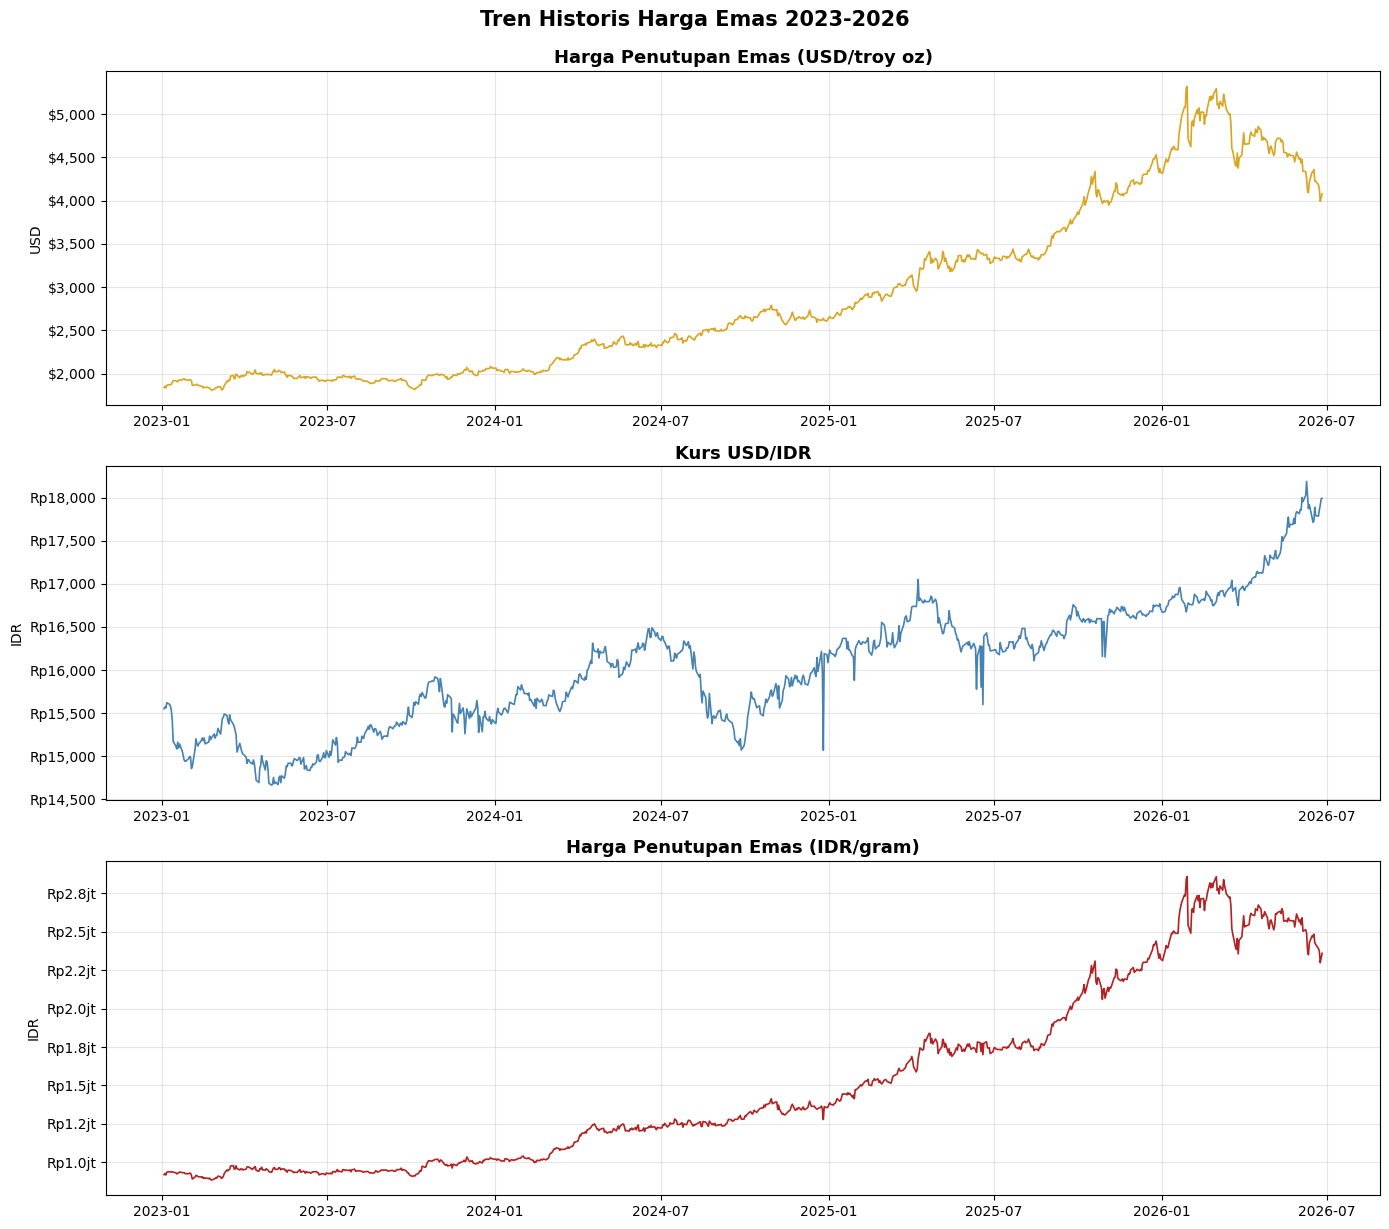

In [209]:
fig, axes = plt.subplots(3,1, figsize=(14, 12))

# Plot 1 : Harga emas dalam USD
axes[0].plot(df.index, df["Close_Gold_USD"], color='goldenrod', linewidth=1.2)
axes[0].set_title('Harga Penutupan Emas (USD/troy oz)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].grid(alpha=0.3)

# Plot 2 : Kurs USD?IDR
axes[1].plot(df.index, df["Close_usdidr"], color='steelblue', linewidth=1.2)
axes[1].set_title('Kurs USD/IDR', fontsize=13, fontweight='bold')
axes[1].set_ylabel('IDR')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('Rp{x:,.0f}'))
axes[1].grid(alpha=0.3)

# Plot 3 : Harga emas dalam Rupiah (IDR)
axes[2].plot(df.index, df["Gold_Close_IDR"], color='firebrick', linewidth=1.2)
axes[2].set_title('Harga Penutupan Emas (IDR/gram)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('IDR')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x/1e6:,.1f}jt'))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Tren Historis Harga Emas 2023-2026', fontsize=15, y=1.02, fontweight='bold')
plt.savefig('/tmp/trend_emas.png', dpi=120, bbox_inches='tight')
plt.show()

***3. Analisis Korelasi***

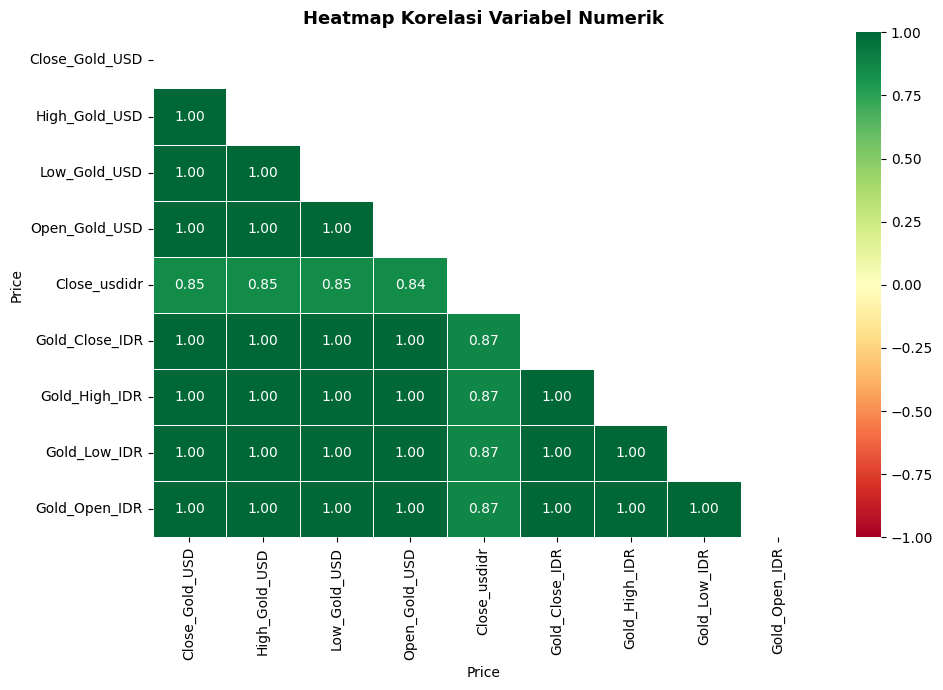

In [210]:
numeric_cols = ['Close_Gold_USD', 'High_Gold_USD', 'Low_Gold_USD', 'Open_Gold_USD',
                'Close_usdidr', 'Gold_Close_IDR', 'Gold_High_IDR', 'Gold_Low_IDR',
                'Gold_Open_IDR']

plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            mask=mask, linewidth=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


***Insight Dari Korelasi Matriks***

>- Harga Emas (Open, High, Low berkorelasi sangat tinggi (1.00) dengan Gold_Close -> hal ini wajar karena (OHLP))
>- USDIDR berkorelasi positif dengan Gold_close_IDR -> kurs ,memperkuat IDR
>- Apabila dolar naik maka harga emas dalam rupiah juga akan naik. Namun, harga emas dunia tetap stabil.

## 3. Feature Engineering

Regresi Linear murni hanya menangkap hubungan linear. Untuk meningkatkan kemampuan prediksi, kita tambahkan **fitur teknikal** berbasis waktu dan statistik:

| Fitur Baru | Deskripsi |
|------------|----------|
| `MA_5`, `MA_20`, `MA_60` | Moving Average 5, 20, 60 hari |
| `EMA_12`, `EMA_26` | Exponential Moving Average |
| `Lag_1`, `Lag_3`, `Lag_7` | Harga IDR hari sebelumnya (1, 3, 7 hari) |
| `Return_1d`, `Return_7d` | Return 1 hari & 7 hari |
| `Volatility_20` | Std dev return 20 hari (ukuran risiko) |
| `Range_IDR` | Selisih High–Low IDR (ukuran fluktuasi harian) |
| `Month`, `DayOfWeek` | Informasi musiman |

In [211]:
df_feat = df.copy()

# Moving Avg
for window in [5, 20, 60]:
  df_feat[f"MA_{window}"] = df_feat["Gold_Close_IDR"].rolling(window).mean()

# Exponential Moving Avg
for window in [12, 26]:
  df_feat[f"EMA_{window}"] = df_feat["Gold_Close_IDR"].ewm(span=window, adjust=False).mean()

# Lag Features
for lag in[1, 3, 7]:
  df_feat[f'lag_{lag}'] = df_feat['Gold_Close_IDR'].shift(lag)

# Returns
for window in [1, 7]:
  df_feat[f'Return_{window}d'] = df_feat['Gold_Close_IDR'].pct_change(window)

# Volatility
df_feat['Volatility_20'] = df_feat['Return_1d'].rolling(20).std()

# Range harian
df_feat['Range_IDR'] = df_feat['Gold_High_IDR'] - df_feat['Gold_Low_IDR']

# Fitur Temporal
df_feat['Month'] = df_feat.index.month
df_feat['DayOfWeek'] = df_feat.index.dayofweek

# hapus baris dengan NaN akibat rolling/lag
df_feat.dropna(inplace=True)

print(f" Feature Engineering Selesai.")
print(f" Jumlah Baris: {df_feat.shape[0]}")
print(f" Jumlah Kolom: {df_feat.shape[1]}")
print("\n Kolom Yang Tersedia")
display(df_feat.columns.tolist())

 Feature Engineering Selesai.
 Jumlah Baris: 846
 Jumlah Kolom: 27

 Kolom Yang Tersedia


['Open_Gold_USD',
 'High_Gold_USD',
 'Low_Gold_USD',
 'Close_Gold_USD',
 'Volume_Gold_USD',
 'Open_usdidr',
 'High_usdidr',
 'Low_usdidr',
 'Close_usdidr',
 'Gold_Close_IDR',
 'Gold_High_IDR',
 'Gold_Low_IDR',
 'Gold_Open_IDR',
 'MA_5',
 'MA_20',
 'MA_60',
 'EMA_12',
 'EMA_26',
 'lag_1',
 'lag_3',
 'lag_7',
 'Return_1d',
 'Return_7d',
 'Volatility_20',
 'Range_IDR',
 'Month',
 'DayOfWeek']

## 4. Pra-proses Data

***1. Penentuan Fitur (X) dan Target (y):***

- **Target (y):** `Gold_Close_IDR` — harga penutupan emas dalam IDR/gram hari ini
- **Fitur (X):** semua kolom fitur teknikal yang telah dibuat

***2. Pembagian Data***

Data dibagi secara **kronologis** (bukan acak) untuk menghindari *data leakage*:
- **80% pertama** → Training
- **20% terakhir** → Testing


In [212]:
# ── Definisi Fitur dan Target ──
feature_cols = [
    'Gold_Open_IDR', 'Gold_High_IDR', 'Gold_Low_IDR',
    'Close_usdidr', 'Volume_Gold_USD',
    'MA_5', 'MA_20', 'MA_60',
    'EMA_12', 'EMA_26',
    'lag_1', 'lag_3', 'lag_7',
    'Return_1d', 'Return_7d',
    'Volatility_20', 'Range_IDR',
    'Month', 'DayOfWeek'
]

X = df_feat[feature_cols]
y = df_feat['Gold_Close_IDR']

# Split Kronologis (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Jumlah data Training : {len(X_train):,} ({len(X_train)/len(x)*100:.1f}%)")
print(f"Jumlah data Testing  : {len(X_test):,}  ({len(X_test)/len(x)*100:.1f}%)")
print(f"Jumlah fitur         : {len(feature_cols)}")
print(f"\nRentang Training : {X_train.index.min().date()} s/d {X_train.index.max().date()}")
print(f"Rentang Testing  : {X_test.index.min().date()}  s/d {X_test.index.max().date()}")


Jumlah data Training : 676 (79.9%)
Jumlah data Testing  : 170  (20.1%)
Jumlah fitur         : 19

Rentang Training : 2023-03-27 s/d 2025-10-29
Rentang Testing  : 2025-10-30  s/d 2026-06-26


## 5. Pelatihan Model

Kita melatih tiga varian model berbasis regresi linear:

***1. Linear Regression (Baseline) ***
Model Regresi Linear standar tanpa regularisasi. Mencari koefisien $\\beta$ yang meminimalkan **Sum of Squared Residuals (SSR)**:
$$\\hat{y} = \\beta_0 + \\beta_1 x_1 + \\beta_2 x_2 + \\cdots + \\beta_n x_n$$
